In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('dermatology_database_1.csv')

In [3]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [4]:
df.shape

(366, 35)

In [5]:
df.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis',
       'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis',
       'clubbing_rete_ridges', 'elongation_rete_ridges',
       'thinning_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_granular_layer', 'vacuolisation_damage_basal_layer',
       'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate',
       'band_like_infiltrate', 'age', 'class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   erythema                             366 non-null    int64 
 1   scaling                              366 non-null    int64 
 2   definite_borders                     366 non-null    int64 
 3   itching                              366 non-null    int64 
 4   koebner_phenomenon                   366 non-null    int64 
 5   polygonal_papules                    366 non-null    int64 
 6   follicular_papules                   366 non-null    int64 
 7   oral_mucosal_involvement             366 non-null    int64 
 8   knee_and_elbow_involvement           366 non-null    int64 
 9   scalp_involvement                    366 non-null    int64 
 10  family_history                       366 non-null    int64 
 11  melanin_incontinence                 366 non-

In [7]:
df['class'].value_counts()

1    112
3     72
2     61
5     52
4     49
6     20
Name: class, dtype: int64

In [5]:
# Convert categorical type data to numeric, with non-numeric like "?" values to NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   erythema                             366 non-null    int64  
 1   scaling                              366 non-null    int64  
 2   definite_borders                     366 non-null    int64  
 3   itching                              366 non-null    int64  
 4   koebner_phenomenon                   366 non-null    int64  
 5   polygonal_papules                    366 non-null    int64  
 6   follicular_papules                   366 non-null    int64  
 7   oral_mucosal_involvement             366 non-null    int64  
 8   knee_and_elbow_involvement           366 non-null    int64  
 9   scalp_involvement                    366 non-null    int64  
 10  family_history                       366 non-null    int64  
 11  melanin_incontinence            

**Impute Missing Value - Numeric Data**

**Check Outlier**

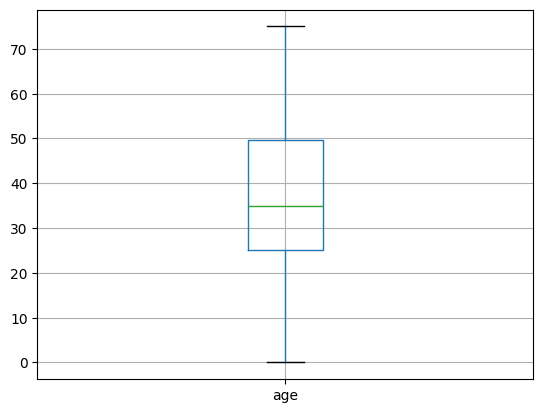

In [6]:
boxplot = df.boxplot(column=['age']) 

In [7]:
#Calculate Mean for age
print(np.mean(df['age']))

36.29608938547486


In [8]:
#Impute missing value with Mean
df['age'].fillna(36.3, inplace=True)

**Split Data into Train and Test Data**

In [9]:
input_df=df.drop('class',axis=1)
output_df=df['class']

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_df, output_df, test_size = 0.2, random_state = 0)

In [11]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

RF_class = RandomForestClassifier(criterion= 'gini',max_depth=4)
RF_class.fit(x_train, y_train)


RandomForestClassifier(max_depth=4)

In [12]:
y_predict=RF_class.predict(x_test)

In [13]:
from sklearn.metrics import classification_report
print('\nClassification Report\n')
print(classification_report(y_test, y_predict, target_names=['1','2','3','4','5','6']))


Classification Report

              precision    recall  f1-score   support

           1       0.94      1.00      0.97        15
           2       1.00      0.93      0.96        14
           3       1.00      1.00      1.00        16
           4       0.92      1.00      0.96        12
           5       1.00      1.00      1.00         9
           6       1.00      0.88      0.93         8

    accuracy                           0.97        74
   macro avg       0.98      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74



**Tuning Parameter using GridSearchCV**

In [41]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'criterion':['gini', 'entropy', 'log_loss'],
    'max_depth':[2,4,6,8,10], 
}

In [42]:
RF_class2 = RandomForestClassifier()
RF_class2= GridSearchCV(RF_class2 ,
                            param_grid = parameters,   # hyperparameters
                            scoring='accuracy',        # metric for scoring
                            cv=5)  

In [43]:
RF_class2.fit(x_train,y_train)
print("Tuned Hyperparameters :", RF_class2.best_params_)
print("Accuracy :",RF_class2.best_score_)

Tuned Hyperparameters : {'criterion': 'log_loss', 'max_depth': 6}
Accuracy : 0.9794856808883694


In [44]:
#Train the data using based parameter
RF_class_best = RandomForestClassifier(criterion= 'log_loss',max_depth=6)

In [45]:
RF_class_best.fit(x_train,y_train)

RandomForestClassifier(criterion='log_loss', max_depth=6)

In [46]:
y_predict_best=RF_class_best.predict(x_test)

In [47]:
print('\nClassification Report\n')
print(classification_report(y_test, y_predict_best, target_names=['1','2','3','4','5','6']))


Classification Report

              precision    recall  f1-score   support

           1       0.94      1.00      0.97        15
           2       1.00      0.93      0.96        14
           3       1.00      1.00      1.00        16
           4       0.92      1.00      0.96        12
           5       1.00      1.00      1.00         9
           6       1.00      0.88      0.93         8

    accuracy                           0.97        74
   macro avg       0.98      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74



**Thank You**